In [1]:
print("Automated Infographic Generator")
print("Project setup successful!")

Automated Infographic Generator
Project setup successful!


In [2]:
import pandas as pd

data = {
    "Category": [
        "Event",
        "Operations",
        "Human Interest",
        "Information",
        "Achievement",
        "Event",
        "Operations",
        "Human Interest"
    ],
    
    "Posts": [
        20,
        15,
        12,
        18,
        10,
        25,
        14,
        16
    ],
    
    "Engagement": [
        450000,
        320000,
        280000,
        210000,
        190000,
        520000,
        300000,
        350000
    ]
}

df = pd.DataFrame(data)

df

,Category,Posts,Engagement
0,Event,20,450000
1,Operations,15,320000
2,Human Interest,12,280000
3,Information,18,210000
4,Achievement,10,190000
5,Event,25,520000
6,Operations,14,300000
7,Human Interest,16,350000


In [8]:
df.to_csv("data/sample_data.csv", index=False)

print("CSV created successfully!")

CSV created successfully!


In [4]:
import os

print(os.getcwd())

C:\Users\omkar\automated_infografic_generator


In [5]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'data', 'output', 'Project_2_Infographic_Generator.ipynb.ipynb']


In [9]:
import pandas as pd

df = pd.read_csv("data/sample_data.csv")

print("Data loaded successfully!")
df

Data loaded successfully!


,Category,Posts,Engagement
0,Event,20,450000
1,Operations,15,320000
2,Human Interest,12,280000
3,Information,18,210000
4,Achievement,10,190000
5,Event,25,520000
6,Operations,14,300000
7,Human Interest,16,350000


In [10]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 8
Number of columns: 3

Column names:
['Category', 'Posts', 'Engagement']

Missing values:
Category      0
Posts         0
Engagement    0
dtype: int64


In [11]:
df = df.drop_duplicates()

df["Posts"] = pd.to_numeric(df["Posts"], errors="coerce")
df["Engagement"] = pd.to_numeric(df["Engagement"], errors="coerce")

df = df.dropna(subset=["Category", "Posts", "Engagement"])

print("Data cleaned successfully!")
print("Rows after cleaning:", len(df))

Data cleaned successfully!
Rows after cleaning: 8


In [12]:
total_categories = len(df)
total_posts = df["Posts"].sum()
total_engagement = df["Engagement"].sum()
average_engagement = df["Engagement"].mean()
highest_engagement = df["Engagement"].max()
lowest_engagement = df["Engagement"].min()

print("========== KEY PERFORMANCE INDICATORS ==========")
print("Categories:", total_categories)
print("Total Posts:", total_posts)
print("Total Engagement:", f"{total_engagement:,.0f}")
print("Average Engagement:", f"{average_engagement:,.0f}")
print("Highest Engagement:", f"{highest_engagement:,.0f}")
print("Lowest Engagement:", f"{lowest_engagement:,.0f}")

========== KEY PERFORMANCE INDICATORS ==========
Categories: 8
Total Posts: 130
Total Engagement: 2,620,000
Average Engagement: 327,500
Highest Engagement: 520,000
Lowest Engagement: 190,000


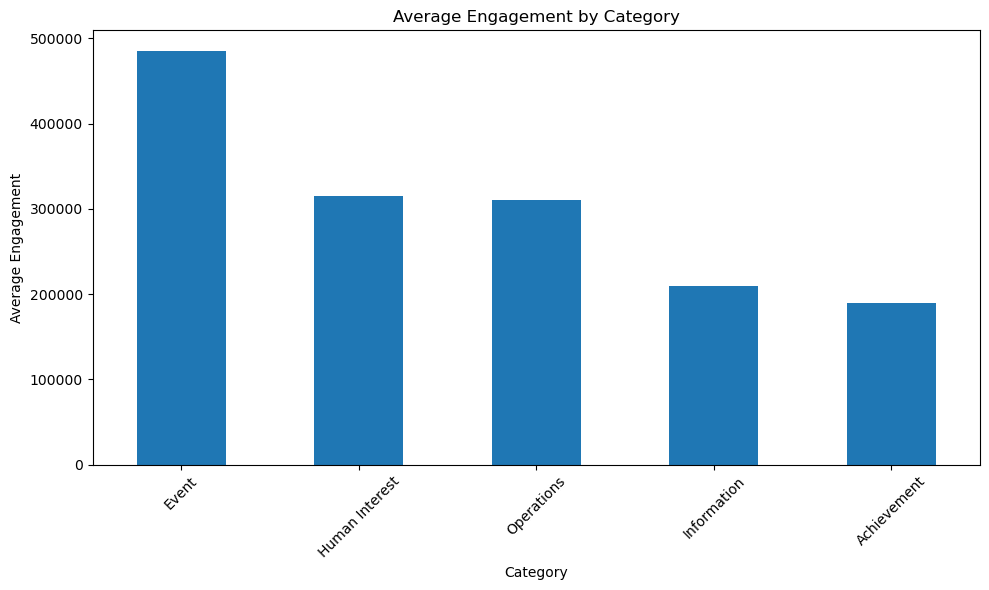

In [13]:
import matplotlib.pyplot as plt

# Calculate average engagement by category
category_engagement = df.groupby("Category")["Engagement"].mean().sort_values(ascending=False)

# Create chart
plt.figure(figsize=(10, 6))

category_engagement.plot(kind="bar")

plt.title("Average Engagement by Category")
plt.xlabel("Category")
plt.ylabel("Average Engagement")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

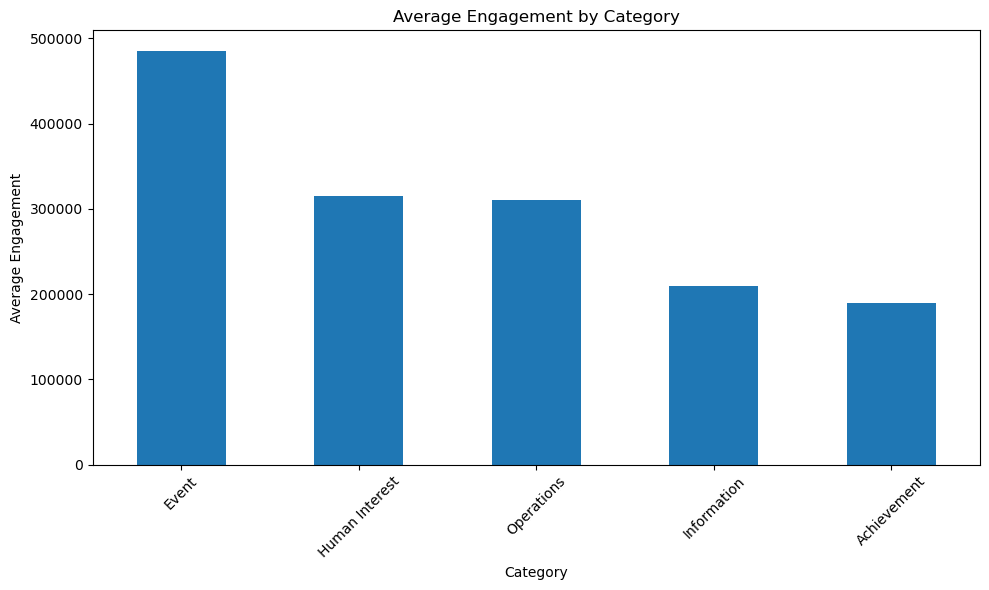

Chart saved successfully!


In [15]:
import os

os.makedirs("output", exist_ok=True)

plt.figure(figsize=(10, 6))

category_engagement.plot(kind="bar")

plt.title("Average Engagement by Category")
plt.xlabel("Category")
plt.ylabel("Average Engagement")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("output/category_engagement.png", dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved successfully!")

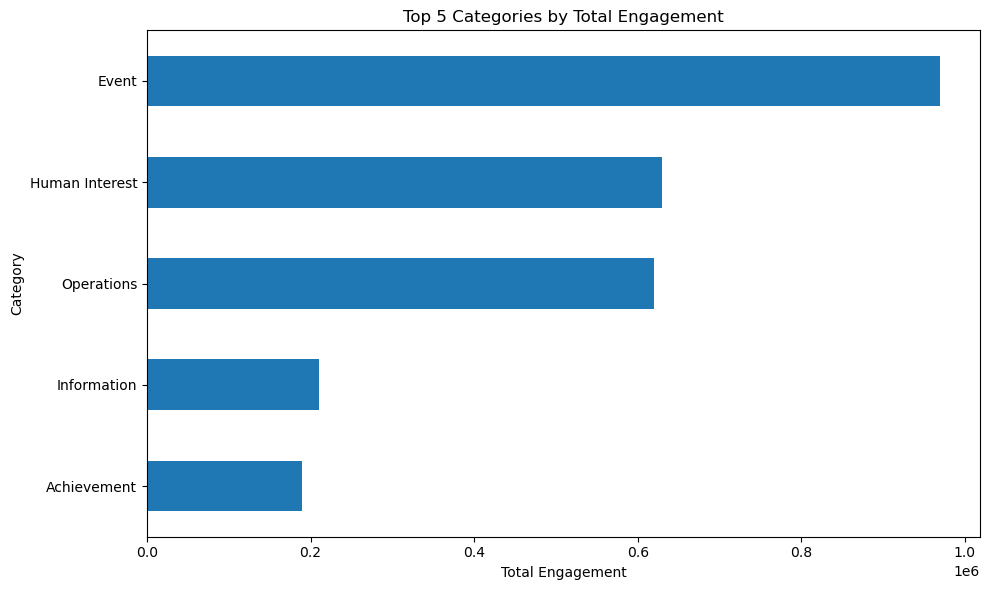

Top categories chart saved successfully!


In [16]:
import matplotlib.pyplot as plt

# Calculate total engagement by category
top_categories = (
    df.groupby("Category")["Engagement"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Create chart
plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 5 Categories by Total Engagement")
plt.xlabel("Total Engagement")
plt.ylabel("Category")

plt.tight_layout()

# Save chart
plt.savefig(
    "output/top_categories_engagement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top categories chart saved successfully!")

In [17]:
# Find best and lowest categories

best_category = category_engagement.idxmax()
best_average = category_engagement.max()

lowest_category = category_engagement.idxmin()
lowest_average = category_engagement.min()

best_category_total = df[df["Category"] == best_category]["Engagement"].sum()
best_category_share = (best_category_total / total_engagement) * 100

print("========== AUTOMATIC INSIGHTS ==========")

print(f"🏆 Best performing category: {best_category}")
print(f"📊 Average engagement: {best_average:,.0f}")

print(f"📉 Lowest performing category: {lowest_category}")
print(f"📊 Average engagement: {lowest_average:,.0f}")

print(f"📈 {best_category} contributes {best_category_share:.1f}% of total engagement.")

========== AUTOMATIC INSIGHTS ==========
🏆 Best performing category: Event
📊 Average engagement: 485,000
📉 Lowest performing category: Achievement
📊 Average engagement: 190,000
📈 Event contributes 37.0% of total engagement.


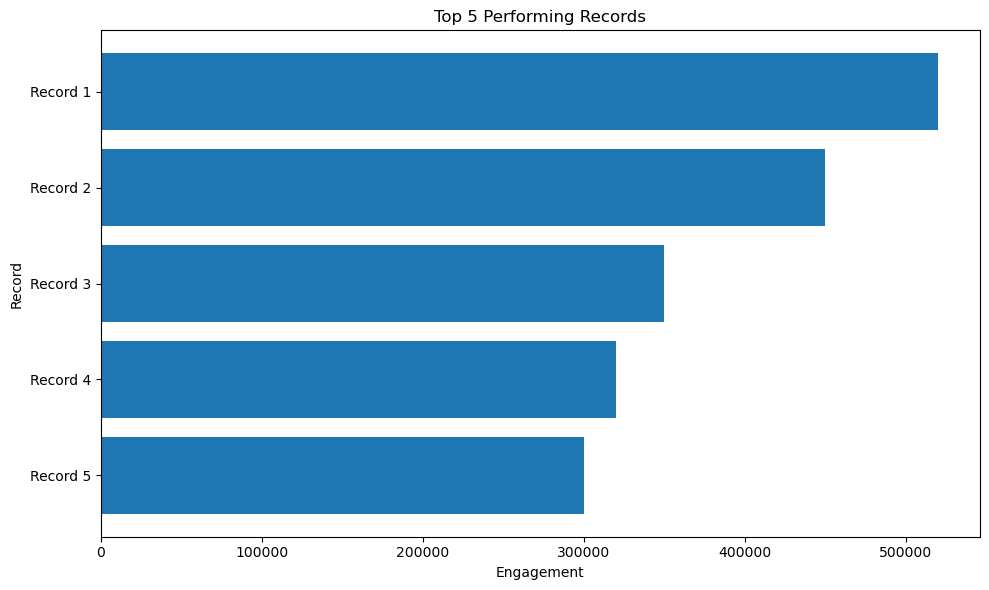

Top 5 records chart saved successfully!


In [18]:
import matplotlib.pyplot as plt

# Get top 5 records by engagement
top_records = df.nlargest(5, "Engagement").copy()

# Create labels
top_records["Record"] = [
    f"Record {i+1}" for i in range(len(top_records))
]

# Sort for horizontal chart
top_records = top_records.sort_values("Engagement")

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_records["Record"],
    top_records["Engagement"]
)

plt.title("Top 5 Performing Records")
plt.xlabel("Engagement")
plt.ylabel("Record")

plt.tight_layout()

# Save chart
plt.savefig(
    "output/top_5_records.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top 5 records chart saved successfully!")

In [19]:
import matplotlib
import pandas

print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pandas.__version__)
print("Libraries are ready!")

Matplotlib version: 3.10.6
Pandas version: 3.0.5
Libraries are ready!


NameError: name 'best_category_share' is not defined

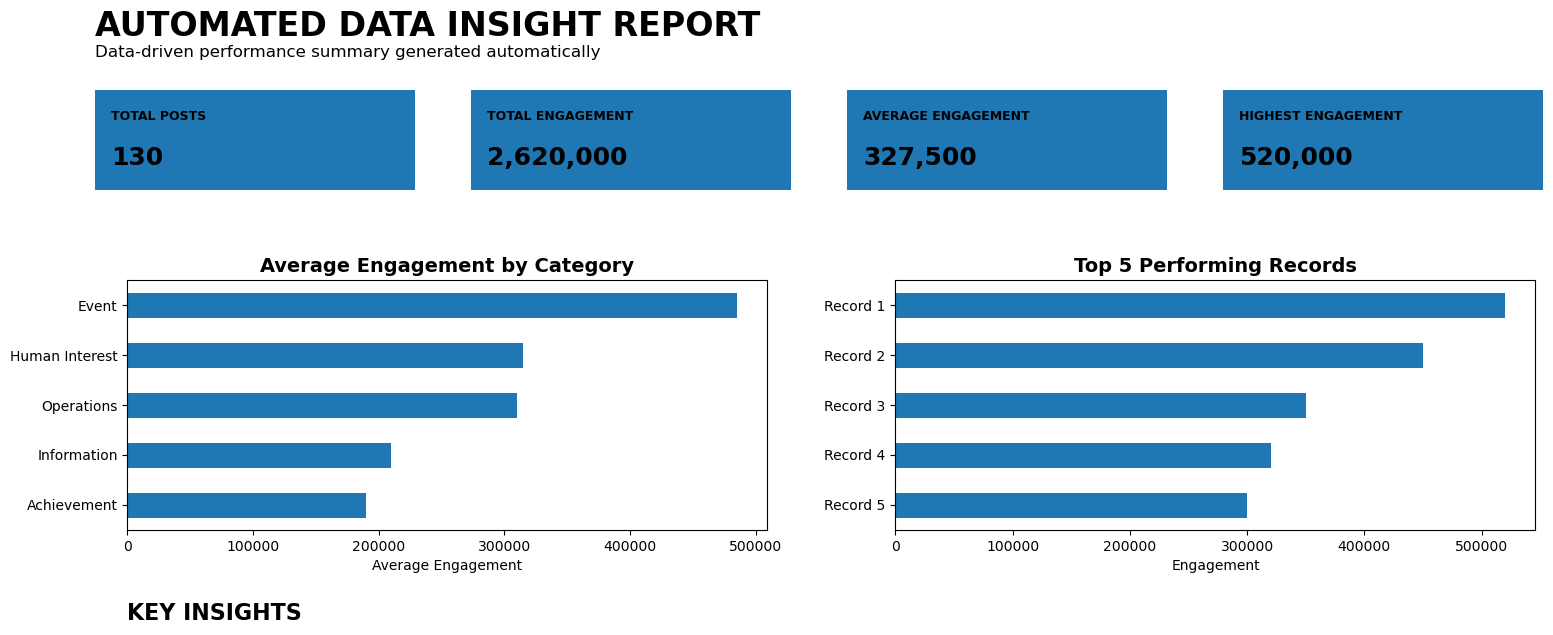

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# Create figure
# -----------------------------
fig = plt.figure(figsize=(16, 10))

fig.patch.set_facecolor("white")

# -----------------------------
# Title
# -----------------------------
fig.text(
    0.05, 0.95,
    "AUTOMATED DATA INSIGHT REPORT",
    fontsize=24,
    fontweight="bold",
    va="top"
)

fig.text(
    0.05, 0.915,
    "Data-driven performance summary generated automatically",
    fontsize=12,
    va="top"
)

# -----------------------------
# KPI values
# -----------------------------
kpis = [
    ("TOTAL POSTS", f"{total_posts:,.0f}"),
    ("TOTAL ENGAGEMENT", f"{total_engagement:,.0f}"),
    ("AVERAGE ENGAGEMENT", f"{average_engagement:,.0f}"),
    ("HIGHEST ENGAGEMENT", f"{highest_engagement:,.0f}")
]

# -----------------------------
# KPI cards
# -----------------------------
x_positions = [0.05, 0.285, 0.52, 0.755]

for x, (label, value) in zip(x_positions, kpis):

    ax = fig.add_axes([x, 0.77, 0.20, 0.10])
    ax.axis("off")

    box = FancyBboxPatch(
        (0, 0),
        1,
        1,
        boxstyle="round,pad=0.02",
        linewidth=1
    )

    ax.add_patch(box)

    ax.text(
        0.05,
        0.70,
        label,
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        0.05,
        0.25,
        value,
        fontsize=18,
        fontweight="bold"
    )

# -----------------------------
# Chart 1
# -----------------------------
ax1 = fig.add_axes([0.07, 0.43, 0.40, 0.25])

category_engagement.sort_values().plot(
    kind="barh",
    ax=ax1
)

ax1.set_title(
    "Average Engagement by Category",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Average Engagement")
ax1.set_ylabel("")

# -----------------------------
# Chart 2
# -----------------------------
ax2 = fig.add_axes([0.55, 0.43, 0.40, 0.25])

top_records.sort_values("Engagement").plot(
    x="Record",
    y="Engagement",
    kind="barh",
    ax=ax2,
    legend=False
)

ax2.set_title(
    "Top 5 Performing Records",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Engagement")
ax2.set_ylabel("")

# -----------------------------
# Insights section
# -----------------------------
fig.text(
    0.07,
    0.34,
    "KEY INSIGHTS",
    fontsize=16,
    fontweight="bold"
)

insight_text = (
    f"• Best performing category: {best_category}\n"
    f"• Average engagement of best category: {best_average:,.0f}\n"
    f"• Lowest performing category: {lowest_category}\n"
    f"• Average engagement of lowest category: {lowest_average:,.0f}\n"
    f"• {best_category} contributes {best_category_share:.1f}% "
    f"of total engagement."
)

fig.text(
    0.07,
    0.17,
    insight_text,
    fontsize=12,
    linespacing=1.8,
    va="top"
)

# -----------------------------
# Footer
# -----------------------------
fig.text(
    0.05,
    0.04,
    "Generated automatically from structured input data",
    fontsize=9
)

# -----------------------------
# Save output
# -----------------------------
plt.savefig(
    "output/executive_infographic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Executive infographic generated successfully!")

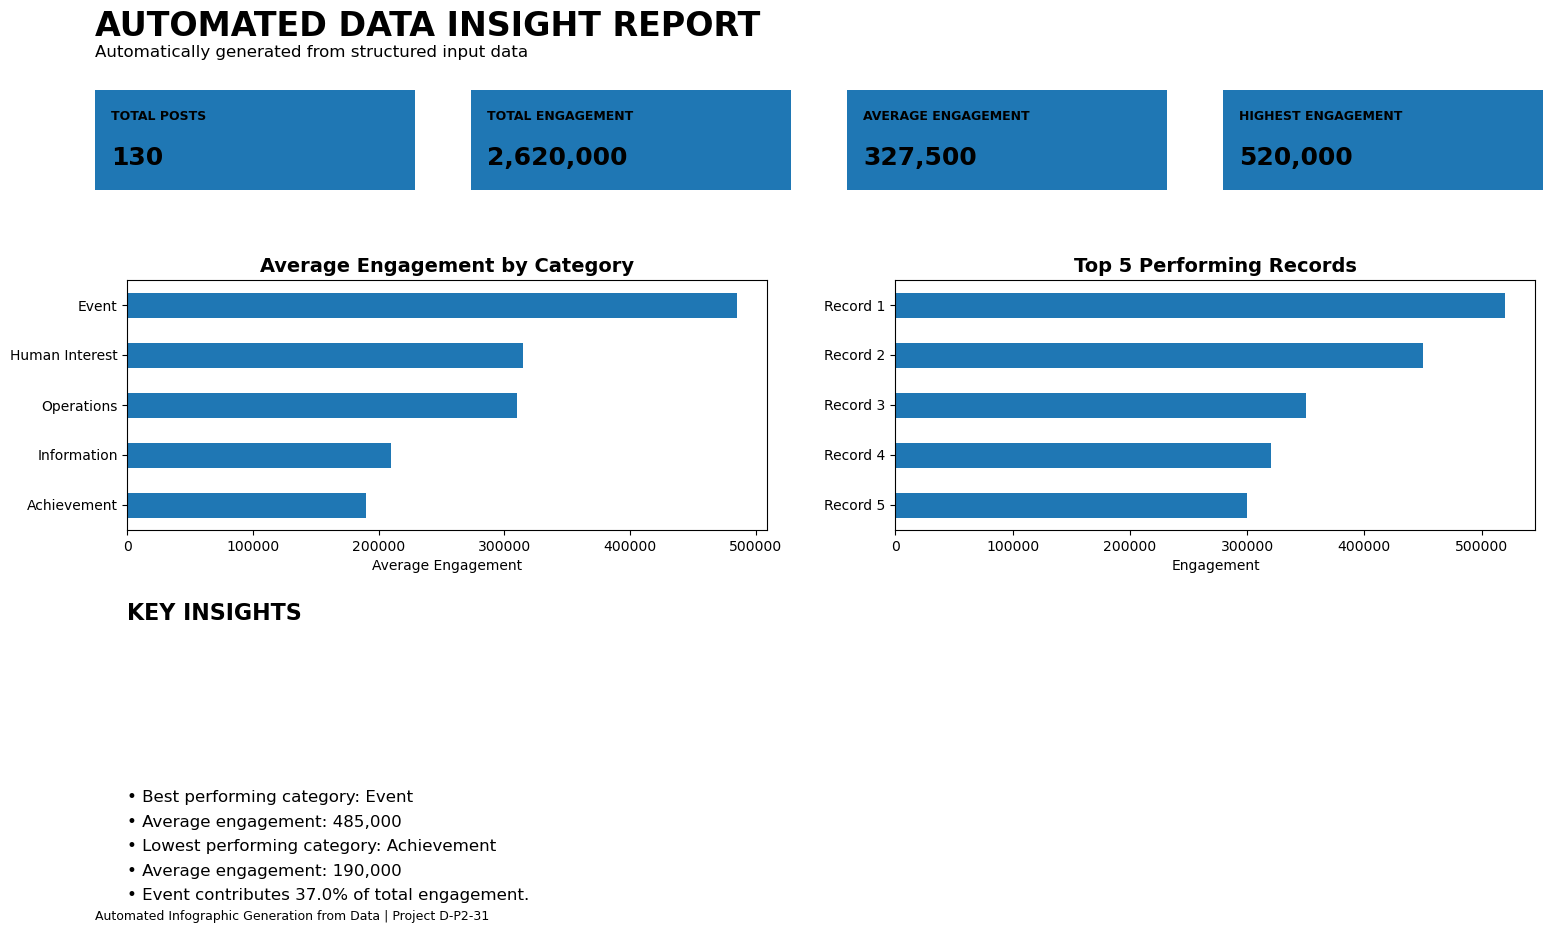

Executive infographic generated successfully!


In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ==========================================
# RECALCULATE ALL VALUES
# ==========================================

total_posts = df["Posts"].sum()
total_engagement = df["Engagement"].sum()
average_engagement = df["Engagement"].mean()
highest_engagement = df["Engagement"].max()
lowest_engagement = df["Engagement"].min()

# Category analysis
category_engagement = (
    df.groupby("Category")["Engagement"]
    .mean()
    .sort_values(ascending=False)
)

best_category = category_engagement.idxmax()
best_average = category_engagement.max()

lowest_category = category_engagement.idxmin()
lowest_average = category_engagement.min()

best_category_total = (
    df[df["Category"] == best_category]["Engagement"].sum()
)

best_category_share = (
    best_category_total / total_engagement
) * 100

# Top 5 records
top_records = df.nlargest(5, "Engagement").copy()

top_records["Record"] = [
    f"Record {i+1}" for i in range(len(top_records))
]

# ==========================================
# CREATE INFOGRAPHIC
# ==========================================

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("white")

# ==========================================
# TITLE
# ==========================================

fig.text(
    0.05, 0.95,
    "AUTOMATED DATA INSIGHT REPORT",
    fontsize=24,
    fontweight="bold",
    va="top"
)

fig.text(
    0.05, 0.915,
    "Automatically generated from structured input data",
    fontsize=12,
    va="top"
)

# ==========================================
# KPI CARDS
# ==========================================

kpis = [
    ("TOTAL POSTS", f"{total_posts:,.0f}"),
    ("TOTAL ENGAGEMENT", f"{total_engagement:,.0f}"),
    ("AVERAGE ENGAGEMENT", f"{average_engagement:,.0f}"),
    ("HIGHEST ENGAGEMENT", f"{highest_engagement:,.0f}")
]

x_positions = [0.05, 0.285, 0.52, 0.755]

for x, (label, value) in zip(x_positions, kpis):

    ax = fig.add_axes([x, 0.77, 0.20, 0.10])
    ax.axis("off")

    box = FancyBboxPatch(
        (0, 0),
        1,
        1,
        boxstyle="round,pad=0.02",
        linewidth=1
    )

    ax.add_patch(box)

    ax.text(
        0.05,
        0.70,
        label,
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        0.05,
        0.25,
        value,
        fontsize=18,
        fontweight="bold"
    )

# ==========================================
# CHART 1
# ==========================================

ax1 = fig.add_axes([0.07, 0.43, 0.40, 0.25])

category_engagement.sort_values().plot(
    kind="barh",
    ax=ax1
)

ax1.set_title(
    "Average Engagement by Category",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Average Engagement")
ax1.set_ylabel("")

# ==========================================
# CHART 2
# ==========================================

ax2 = fig.add_axes([0.55, 0.43, 0.40, 0.25])

top_records.sort_values("Engagement").plot(
    x="Record",
    y="Engagement",
    kind="barh",
    ax=ax2,
    legend=False
)

ax2.set_title(
    "Top 5 Performing Records",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Engagement")
ax2.set_ylabel("")

# ==========================================
# INSIGHTS
# ==========================================

fig.text(
    0.07,
    0.34,
    "KEY INSIGHTS",
    fontsize=16,
    fontweight="bold"
)

insight_text = (
    f"• Best performing category: {best_category}\n"
    f"• Average engagement: {best_average:,.0f}\n"
    f"• Lowest performing category: {lowest_category}\n"
    f"• Average engagement: {lowest_average:,.0f}\n"
    f"• {best_category} contributes {best_category_share:.1f}% "
    f"of total engagement."
)

fig.text(
    0.07,
    0.17,
    insight_text,
    fontsize=12,
    linespacing=1.8,
    va="top"
)

# ==========================================
# FOOTER
# ==========================================

fig.text(
    0.05,
    0.04,
    "Automated Infographic Generation from Data | Project D-P2-31",
    fontsize=9
)

# ==========================================
# SAVE
# ==========================================

plt.savefig(
    "output/executive_infographic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Executive infographic generated successfully!")

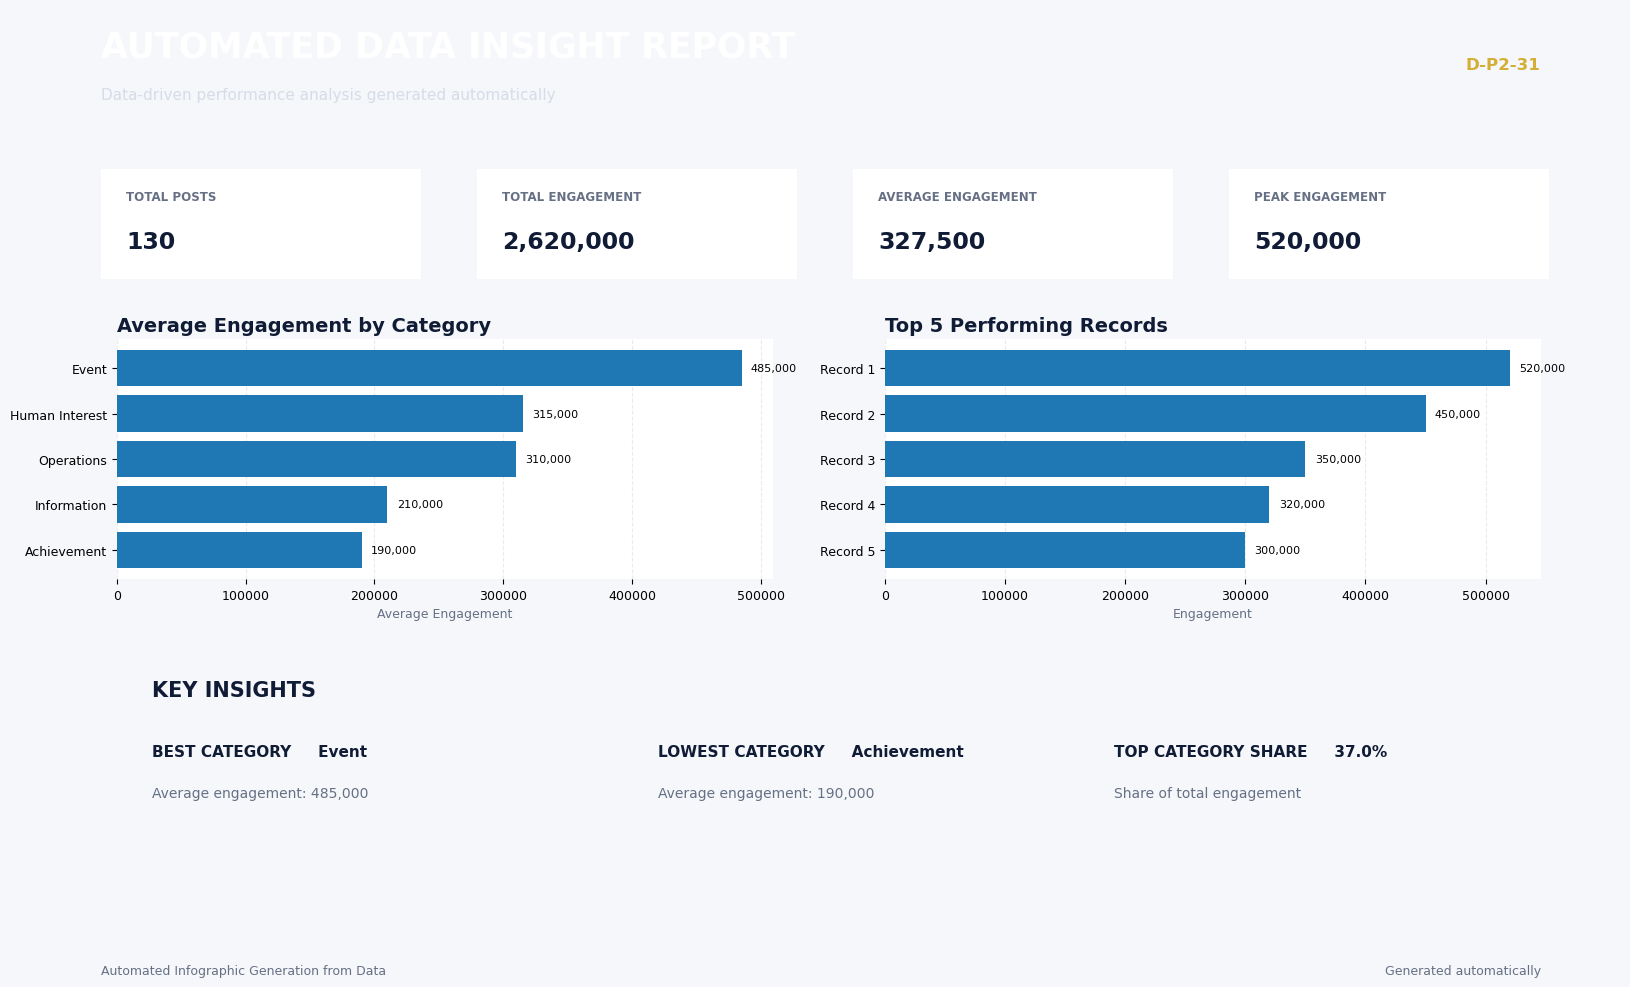

Professional infographic generated successfully!


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================

df = pd.read_csv("data/sample_data.csv")

# Clean data
df = df.drop_duplicates()

df["Posts"] = pd.to_numeric(df["Posts"], errors="coerce")
df["Engagement"] = pd.to_numeric(df["Engagement"], errors="coerce")

df = df.dropna(subset=["Category", "Posts", "Engagement"])

# ============================================================
# 2. CALCULATE KPIs
# ============================================================

total_posts = df["Posts"].sum()
total_engagement = df["Engagement"].sum()
average_engagement = df["Engagement"].mean()
highest_engagement = df["Engagement"].max()
lowest_engagement = df["Engagement"].min()

# Category analysis
category_engagement = (
    df.groupby("Category")["Engagement"]
    .mean()
    .sort_values(ascending=False)
)

best_category = category_engagement.idxmax()
best_average = category_engagement.max()

lowest_category = category_engagement.idxmin()
lowest_average = category_engagement.min()

best_category_total = (
    df[df["Category"] == best_category]["Engagement"].sum()
)

best_category_share = (
    best_category_total / total_engagement
) * 100

# Top 5 records
top_records = df.nlargest(5, "Engagement").copy()

top_records["Record"] = [
    f"Record {i+1}"
    for i in range(len(top_records))
]

# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig = plt.figure(figsize=(16, 10))

fig.patch.set_facecolor("#F5F7FA")

# ============================================================
# 4. HEADER
# ============================================================

header = fig.add_axes([0, 0.88, 1, 0.12])
header.set_facecolor("#101C36")
header.axis("off")

header.text(
    0.05,
    0.60,
    "AUTOMATED DATA INSIGHT REPORT",
    fontsize=25,
    fontweight="bold",
    color="white"
)

header.text(
    0.05,
    0.25,
    "Data-driven performance analysis generated automatically",
    fontsize=11,
    color="#D6DCE8"
)

header.text(
    0.95,
    0.50,
    "D-P2-31",
    fontsize=12,
    fontweight="bold",
    color="#D4AF37",
    ha="right"
)

# ============================================================
# 5. KPI CARDS
# ============================================================

kpis = [
    ("TOTAL POSTS", f"{total_posts:,.0f}"),
    ("TOTAL ENGAGEMENT", f"{total_engagement:,.0f}"),
    ("AVERAGE ENGAGEMENT", f"{average_engagement:,.0f}"),
    ("PEAK ENGAGEMENT", f"{highest_engagement:,.0f}")
]

x_positions = [0.05, 0.285, 0.52, 0.755]

for x, (label, value) in zip(x_positions, kpis):

    ax = fig.add_axes([x, 0.73, 0.20, 0.11])
    ax.set_facecolor("white")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Card border
    card = FancyBboxPatch(
        (0, 0),
        1,
        1,
        boxstyle="round,pad=0.015,rounding_size=0.04",
        linewidth=1.2,
        edgecolor="#D9DEE8",
        facecolor="white"
    )

    ax.add_patch(card)

    ax.text(
        0.08,
        0.72,
        label,
        fontsize=8.5,
        fontweight="bold",
        color="#667085"
    )

    ax.text(
        0.08,
        0.28,
        value,
        fontsize=17,
        fontweight="bold",
        color="#101C36"
    )

# ============================================================
# 6. CATEGORY CHART
# ============================================================

ax1 = fig.add_axes([0.06, 0.43, 0.41, 0.24])

category_sorted = category_engagement.sort_values()

bars = ax1.barh(
    category_sorted.index,
    category_sorted.values
)

ax1.set_title(
    "Average Engagement by Category",
    fontsize=14,
    fontweight="bold",
    loc="left",
    color="#101C36"
)

ax1.set_xlabel(
    "Average Engagement",
    fontsize=9,
    color="#667085"
)

ax1.tick_params(
    axis="both",
    labelsize=9
)

ax1.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax1.set_axisbelow(True)

for spine in ax1.spines.values():
    spine.set_visible(False)

# Add values to bars
for bar in bars:

    value = bar.get_width()

    ax1.text(
        value + (category_engagement.max() * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=8
    )

# ============================================================
# 7. TOP 5 RECORDS CHART
# ============================================================

ax2 = fig.add_axes([0.54, 0.43, 0.41, 0.24])

top_sorted = top_records.sort_values("Engagement")

bars2 = ax2.barh(
    top_sorted["Record"],
    top_sorted["Engagement"]
)

ax2.set_title(
    "Top 5 Performing Records",
    fontsize=14,
    fontweight="bold",
    loc="left",
    color="#101C36"
)

ax2.set_xlabel(
    "Engagement",
    fontsize=9,
    color="#667085"
)

ax2.tick_params(
    axis="both",
    labelsize=9
)

ax2.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax2.set_axisbelow(True)

for spine in ax2.spines.values():
    spine.set_visible(False)

# Add values
for bar in bars2:

    value = bar.get_width()

    ax2.text(
        value + (highest_engagement * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=8
    )

# ============================================================
# 8. KEY INSIGHTS PANEL
# ============================================================

insight_ax = fig.add_axes([0.06, 0.12, 0.89, 0.23])

insight_ax.set_facecolor("white")
insight_ax.axis("off")

for spine in insight_ax.spines.values():
    spine.set_visible(False)

insight_ax.text(
    0.025,
    0.84,
    "KEY INSIGHTS",
    fontsize=15,
    fontweight="bold",
    color="#101C36"
)

insight_ax.text(
    0.025,
    0.58,
    f"BEST CATEGORY     {best_category}",
    fontsize=11,
    fontweight="bold",
    color="#101C36"
)

insight_ax.text(
    0.025,
    0.40,
    f"Average engagement: {best_average:,.0f}",
    fontsize=10,
    color="#667085"
)

insight_ax.text(
    0.38,
    0.58,
    f"LOWEST CATEGORY     {lowest_category}",
    fontsize=11,
    fontweight="bold",
    color="#101C36"
)

insight_ax.text(
    0.38,
    0.40,
    f"Average engagement: {lowest_average:,.0f}",
    fontsize=10,
    color="#667085"
)

insight_ax.text(
    0.70,
    0.58,
    f"TOP CATEGORY SHARE     {best_category_share:.1f}%",
    fontsize=11,
    fontweight="bold",
    color="#101C36"
)

insight_ax.text(
    0.70,
    0.40,
    "Share of total engagement",
    fontsize=10,
    color="#667085"
)

# ============================================================
# 9. FOOTER
# ============================================================

fig.text(
    0.05,
    0.035,
    "Automated Infographic Generation from Data",
    fontsize=9,
    color="#667085"
)

fig.text(
    0.95,
    0.035,
    "Generated automatically",
    fontsize=9,
    color="#667085",
    ha="right"
)

# ============================================================
# 10. SAVE
# ============================================================

plt.savefig(
    "output/executive_infographic_pro.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Professional infographic generated successfully!")

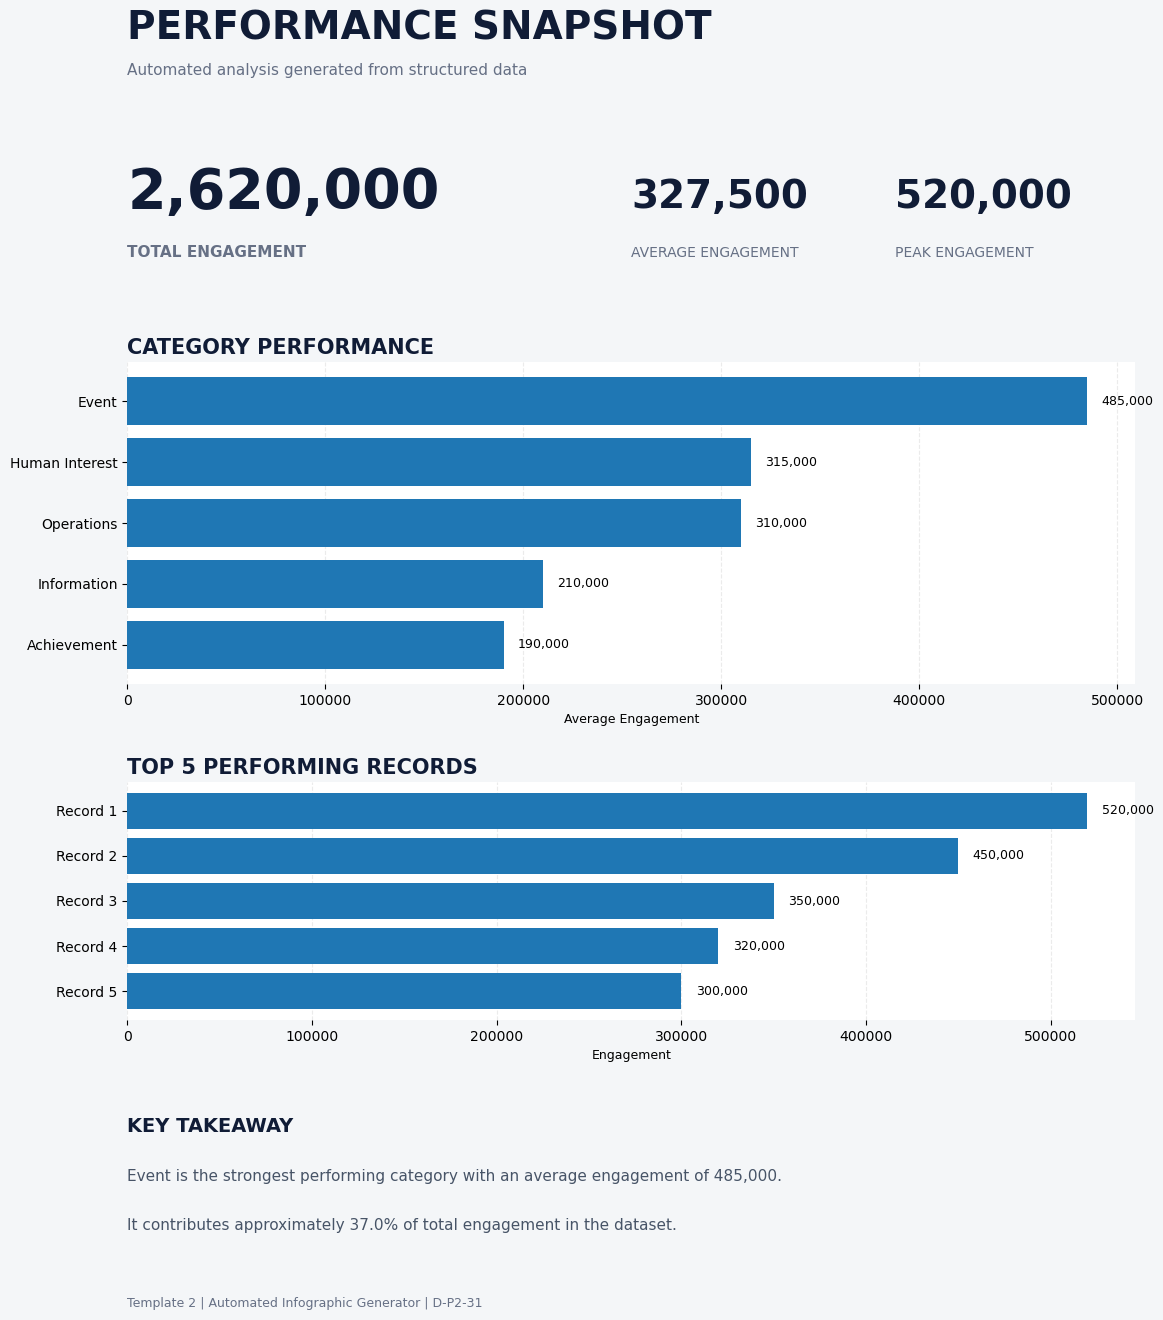

Template 2 generated successfully!


In [23]:
import matplotlib.pyplot as plt

# ==========================================
# TEMPLATE 2
# VISUAL PERFORMANCE REPORT
# ==========================================

# Create figure
fig = plt.figure(figsize=(12, 14))
fig.patch.set_facecolor("#F4F6F8")

# ==========================================
# HEADER
# ==========================================

fig.text(
    0.08,
    0.95,
    "PERFORMANCE SNAPSHOT",
    fontsize=28,
    fontweight="bold",
    color="#101C36"
)

fig.text(
    0.08,
    0.925,
    "Automated analysis generated from structured data",
    fontsize=11,
    color="#667085"
)

# ==========================================
# MAIN KPI
# ==========================================

fig.text(
    0.08,
    0.83,
    f"{total_engagement:,.0f}",
    fontsize=40,
    fontweight="bold",
    color="#101C36"
)

fig.text(
    0.08,
    0.795,
    "TOTAL ENGAGEMENT",
    fontsize=11,
    fontweight="bold",
    color="#667085"
)

# ==========================================
# SECONDARY KPIs
# ==========================================

fig.text(
    0.50,
    0.83,
    f"{average_engagement:,.0f}",
    fontsize=28,
    fontweight="bold",
    color="#101C36"
)

fig.text(
    0.50,
    0.795,
    "AVERAGE ENGAGEMENT",
    fontsize=10,
    color="#667085"
)

fig.text(
    0.72,
    0.83,
    f"{highest_engagement:,.0f}",
    fontsize=28,
    fontweight="bold",
    color="#101C36"
)

fig.text(
    0.72,
    0.795,
    "PEAK ENGAGEMENT",
    fontsize=10,
    color="#667085"
)

# ==========================================
# CATEGORY PERFORMANCE
# ==========================================

ax1 = fig.add_axes([0.08, 0.49, 0.84, 0.23])

category_sorted = category_engagement.sort_values()

bars = ax1.barh(
    category_sorted.index,
    category_sorted.values
)

ax1.set_title(
    "CATEGORY PERFORMANCE",
    fontsize=15,
    fontweight="bold",
    loc="left",
    color="#101C36"
)

ax1.set_xlabel(
    "Average Engagement",
    fontsize=9
)

ax1.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax1.set_axisbelow(True)

for spine in ax1.spines.values():
    spine.set_visible(False)

# Add values
for bar in bars:

    value = bar.get_width()

    ax1.text(
        value + category_engagement.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

# ==========================================
# TOP RECORDS
# ==========================================

ax2 = fig.add_axes([0.08, 0.25, 0.84, 0.17])

top_sorted = top_records.sort_values("Engagement")

bars2 = ax2.barh(
    top_sorted["Record"],
    top_sorted["Engagement"]
)

ax2.set_title(
    "TOP 5 PERFORMING RECORDS",
    fontsize=15,
    fontweight="bold",
    loc="left",
    color="#101C36"
)

ax2.set_xlabel(
    "Engagement",
    fontsize=9
)

ax2.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax2.set_axisbelow(True)

for spine in ax2.spines.values():
    spine.set_visible(False)

for bar in bars2:

    value = bar.get_width()

    ax2.text(
        value + highest_engagement * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

# ==========================================
# INSIGHT BOX
# ==========================================

fig.text(
    0.08,
    0.17,
    "KEY TAKEAWAY",
    fontsize=14,
    fontweight="bold",
    color="#101C36"
)

fig.text(
    0.08,
    0.135,
    f"{best_category} is the strongest performing category "
    f"with an average engagement of {best_average:,.0f}.",
    fontsize=11,
    color="#475467"
)

fig.text(
    0.08,
    0.10,
    f"It contributes approximately {best_category_share:.1f}% "
    f"of total engagement in the dataset.",
    fontsize=11,
    color="#475467"
)

# ==========================================
# FOOTER
# ==========================================

fig.text(
    0.08,
    0.045,
    "Template 2 | Automated Infographic Generator | D-P2-31",
    fontsize=9,
    color="#667085"
)

# ==========================================
# SAVE
# ==========================================

plt.savefig(
    "output/template_2_visual_report.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Template 2 generated successfully!")

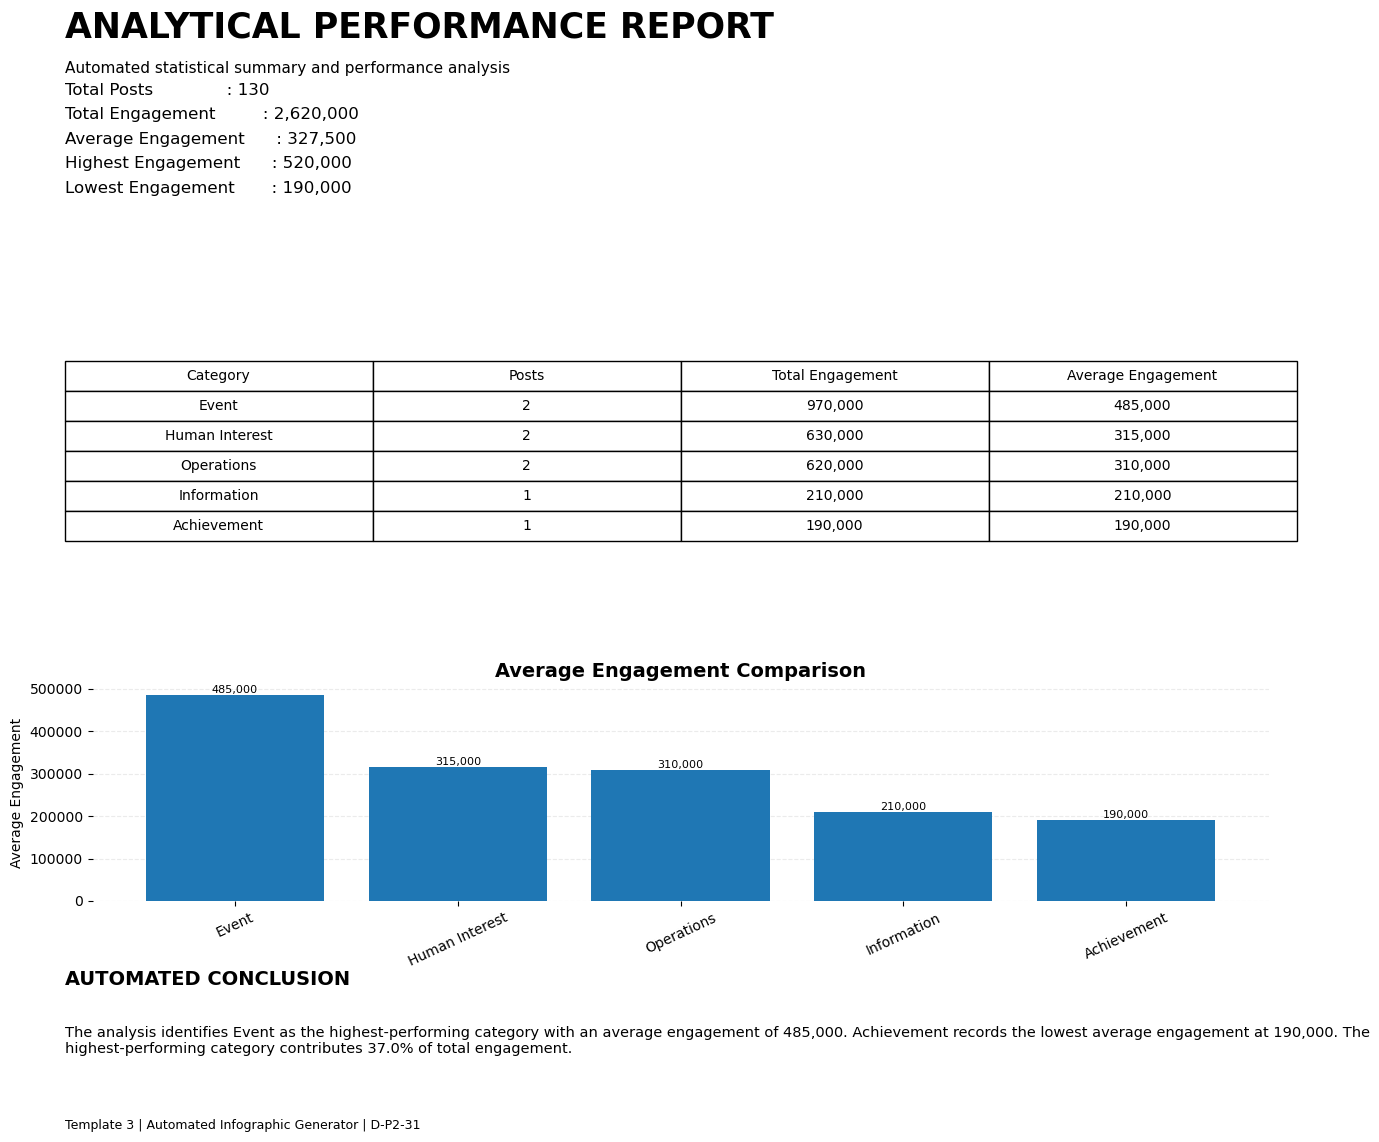

Template 3 generated successfully!


In [24]:
import matplotlib.pyplot as plt

# ==========================================
# TEMPLATE 3 - ANALYTICAL REPORT
# ==========================================

fig = plt.figure(figsize=(14, 12))
fig.patch.set_facecolor("white")

# ==========================================
# TITLE
# ==========================================

fig.text(
    0.06, 0.95,
    "ANALYTICAL PERFORMANCE REPORT",
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.06, 0.92,
    "Automated statistical summary and performance analysis",
    fontsize=11
)

# ==========================================
# STATISTICS
# ==========================================

stats_text = (
    f"Total Posts              : {total_posts:,.0f}\n"
    f"Total Engagement         : {total_engagement:,.0f}\n"
    f"Average Engagement      : {average_engagement:,.0f}\n"
    f"Highest Engagement      : {highest_engagement:,.0f}\n"
    f"Lowest Engagement       : {lowest_engagement:,.0f}"
)

fig.text(
    0.06,
    0.82,
    stats_text,
    fontsize=12,
    linespacing=1.8
)

# ==========================================
# CATEGORY TABLE
# ==========================================

category_table = (
    df.groupby("Category")["Engagement"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

category_table.columns = [
    "Posts",
    "Total Engagement",
    "Average Engagement"
]

ax_table = fig.add_axes([0.06, 0.48, 0.88, 0.25])
ax_table.axis("off")

table_data = []

for category, row in category_table.iterrows():

    table_data.append([
        category,
        int(row["Posts"]),
        f"{row['Total Engagement']:,.0f}",
        f"{row['Average Engagement']:,.0f}"
    ])

table = ax_table.table(
    cellText=table_data,
    colLabels=[
        "Category",
        "Posts",
        "Total Engagement",
        "Average Engagement"
    ],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# ==========================================
# CATEGORY VISUAL
# ==========================================

ax = fig.add_axes([0.08, 0.23, 0.84, 0.18])

bars = ax.bar(
    category_engagement.index,
    category_engagement.values
)

ax.set_title(
    "Average Engagement Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Average Engagement")

ax.tick_params(
    axis="x",
    rotation=25
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar in bars:

    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# ==========================================
# AUTOMATED CONCLUSION
# ==========================================

fig.text(
    0.06,
    0.16,
    "AUTOMATED CONCLUSION",
    fontsize=14,
    fontweight="bold"
)

conclusion = (
    f"The analysis identifies {best_category} as the highest-performing "
    f"category with an average engagement of {best_average:,.0f}. "
    f"{lowest_category} records the lowest average engagement at "
    f"{lowest_average:,.0f}. The highest-performing category contributes "
    f"{best_category_share:.1f}% of total engagement."
)

fig.text(
    0.06,
    0.105,
    conclusion,
    fontsize=10.5,
    wrap=True
)

# ==========================================
# FOOTER
# ==========================================

fig.text(
    0.06,
    0.04,
    "Template 3 | Automated Infographic Generator | D-P2-31",
    fontsize=9
)

# ==========================================
# SAVE
# ==========================================

plt.savefig(
    "output/template_3_analytical_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Template 3 generated successfully!")

In [25]:
!pip install streamlit

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 9.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.0 MB 9.4 MB/s eta 0:00:01
   ------------ --------------------------- 3.4/11.0 MB 7.3 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 5.6 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/11.0 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/11.0 MB 4.8 MB/s eta 0:00:02
   ----------------- ---------------------- 4.7/11.0 MB 3.8 MB/s eta 0:00:02
   ------------------ --------------------- 5.0/11.0 MB 3.1 MB/s eta 0:00:02
   ------------------ --------------------- 5.0/11.0 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/11.0 MB 2.7 MB/s eta 0:00:03
   -------------------- ------------------- 5.5/11.0 MB 2.5 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.0 MB 2.4 MB/s eta 0:00:03
   ---

  You can safely remove it manually.
  You can safely remove it manually.


In [26]:
import streamlit

print("Streamlit is installed!")

Streamlit is installed!


In [27]:
import os
print(os.getcwd())

C:\Users\omkar\automated_infografic_generator


In [ ]:
import os
print(os.getcwd())
print(os.path.exists("app.py"))

In [ ]:
!start "" cmd /k "python -m streamlit run app.py"

In [ ]:
import os
print(os.getcwd())
print(os.path.exists("app.py"))